# Compariason Scikit-Learn / spark

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

PROJECT_DIR = Path().cwd().parent.resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "output"
METRIC_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"
SKLEARN_RESULTS_PATH = METRIC_DIR / "model_comparisons.csv"
SPARK_RESULTS_PATH = METRIC_DIR / "model_comparison_spark.csv"

In [2]:
# Accessibilité : Daltonisme, Dyslexie, Confort Visuel

sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

## Chargement des données

In [3]:
df_sklearn = pd.read_csv(SKLEARN_RESULTS_PATH)
df_sklearn["Library"] = "SciKit-Learn"
df_spark = pd.read_csv(SPARK_RESULTS_PATH)
df_spark["Library"] = "Spark-MLlib"

df = pd.concat([df_sklearn, df_spark])

## Analyse

In [4]:
df.sort_values("Recall Yes", ascending=False).head()

,Model,Accuracy,Precision Yes,Precision No,Precision Weighted,Recall Yes,Recall No,Recall Weighted,F1 Yes,F1 No,F1 Weighted,Time,Library
6,lr_balanced_feat_eng,0.620445,0.215103,0.906376,0.806922,0.618421,0.620785,0.620445,0.319185,0.736877,0.676783,0.034605,SciKit-Learn
0,rfc_balanced,0.675137,0.244784,0.915373,0.820147,0.617544,0.684669,0.675137,0.350598,0.783389,0.721931,2.820549,Spark-MLlib
1,lr_balanced_naive,0.618079,0.213227,0.905340,0.805765,0.615132,0.618574,0.618079,0.316681,0.734975,0.674795,0.031406,SciKit-Learn
2,rfc_naive,0.852343,0.404762,0.861420,0.795720,0.055921,0.986180,0.852343,0.098266,0.919588,0.801423,0.385613,SciKit-Learn
7,rfc_feat_eng,0.851869,0.390244,0.861004,0.793275,0.052632,0.986180,0.851869,0.092754,0.919351,0.800427,0.391207,SciKit-Learn


Observations :
- Pour Scikit-learn, le meilleur modèle est LogistiqueRegression ayant pour paramètre class_weight="balanced".
- Pour Spark, le meilleur modèle est RandomForestClassifier ayant pour paramètre weightCol="weight".
- Les deux modèles ont des métriques semblables avec un *F1 score* légérement meilleur pour le RandomForestClassifier de Spark.
- Le temps d'exécution est meilleur pour Scikit-Learn car nous avons un petit dataset.

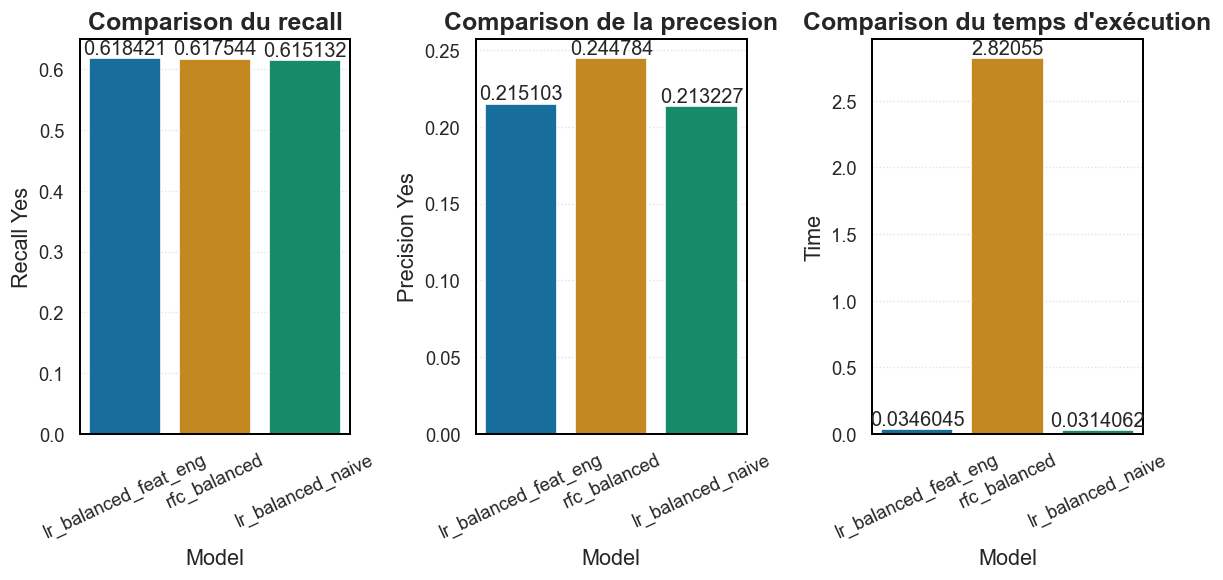

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ax1 = axes[0]
barplot1 = sns.barplot(
    data=df.nlargest(3, "Recall Yes"),
    x="Model",
    y="Recall Yes",
    palette="colorblind",
    hue="Model",
    legend=False,
    ax=ax1,
)

for container in barplot1.containers:
    barplot1.bar_label(container)

ax1.tick_params(axis="x", rotation=25)
ax1.set_title("Comparison du recall")

ax2 = axes[1]
barplot2 = sns.barplot(
    data=df.nlargest(3, "Recall Yes"),
    x="Model",
    y="Precision Yes",
    palette="colorblind",
    hue="Model",
    legend=False,
    ax=ax2,
)

for container in barplot2.containers:
    barplot2.bar_label(container)

ax2.tick_params(axis="x", rotation=25)
ax2.set_title("Comparison de la precesion")

ax3 = axes[2]
barplot3 = sns.barplot(
    data=df.nlargest(3, "Recall Yes"),
    x="Model",
    y="Time",
    palette="colorblind",
    hue="Model",
    legend=False,
    ax=ax3,
)

for container in barplot3.containers:
    barplot3.bar_label(container)

ax3.tick_params(axis="x", rotation=25)
ax3.set_title("Comparison du temps d'exécution")

fig.tight_layout()
plt.savefig((FIGURE_DIR / "06_scikit_learn_spark_comparison.png").as_posix())
plt.show()